# 06 — Full Pipeline Evaluation (Language-Specific, Full Data)

**Goal:** Fit language-specific RDS scores on the **full 88M-row training set**, evaluate on the **full test set** using importance sampling, and measure lift.

**Key change:** Instead of one global model, we compute **separate RDS scores per language**. Template A might work great for English but poorly for Spanish — language-specific modeling captures this.

**Memory:** Chunked processing — peak RAM ~1-2 GB.

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from src.bandit.rds_policy import RDSPolicy
from src.evaluation.baseline import compute_random_baseline, compute_lift

sns.set_style("whitegrid")
print("Ready!")

Ready!


---
## 1. Configuration

We use **chunked processing** so the full dataset never has to fit in memory at once. Each chunk is ~1M rows ≈ 150-200 MB.

In [2]:
# Chunk size: 1M rows per chunk
CHUNK_SIZE = 1_000_000

# ---- Paper-accurate hyperparameters ----
KAPPA = 1000            # Only used if use_smoothing=True
GAMMA = 0.017           # Paper optimal (Table 4)
H = 15                  # Half-life in days (Paper optimal)
TAU = 0.0025            # Paper convention: score/tau (smaller = greedier)

# Paper offline eval settings (Section 3.1)
USE_SMOOTHING = False   # "we did not use empirical Bayes (sigma=0)"
USE_ARGMAX = True       # "we used argmax instead of softmax"

# Language-specific
MIN_LANG_COUNT = 50_000

# Evaluation: None = use ALL test data
EVAL_SAMPLE_SIZE = None
MAX_WEIGHT = 20

print(f"Chunk size:         {CHUNK_SIZE:,} rows")
print(f"Hyperparameters:    κ={KAPPA}, γ={GAMMA}, h={H}, τ={TAU}")
print(f"Smoothing:          {'ON' if USE_SMOOTHING else 'OFF (paper offline mode)'}")
print(f"Selection:          {'ARGMAX (greedy)' if USE_ARGMAX else f'Softmax τ={TAU}'}")
print(f"Min lang count:     {MIN_LANG_COUNT:,}")
print(f"Eval sample size:   {'FULL TEST SET' if EVAL_SAMPLE_SIZE is None else f'{EVAL_SAMPLE_SIZE:,}'}")
print(f"Max weight:         {MAX_WEIGHT}")

Chunk size:         1,000,000 rows
Hyperparameters:    κ=1000, γ=0.017, h=15, τ=0.0025
Smoothing:          OFF (paper offline mode)
Selection:          ARGMAX (greedy)
Min lang count:     50,000
Eval sample size:   FULL TEST SET
Max weight:         20


---
## 2. Fit the RDS Policy BY LANGUAGE (Full Training Data)

Two passes over all 88M training rows:
- **Pass 1:** Per-(language, template) reward sums → language-specific reward rates
- **Pass 2:** Per-(language, template) RDS scores using language-specific baselines
- Then Bayesian smoothing per language + global fallback for rare languages

In [3]:
import pickle

POLICY_CACHE = os.path.join("..", "data", "intermediate", "policy_by_language_v2.pkl")

if os.path.exists(POLICY_CACHE):
    print("✅ Loading cached policy from disk...")
    with open(POLICY_CACHE, "rb") as f:
        policy = pickle.load(f)
    policy.gamma = GAMMA
    policy.h = H
    policy.tau = TAU
    policy.use_argmax = USE_ARGMAX
    fit_time = 0
    print(f"   Loaded! {len(policy.lang_smoothed_scores)} languages, "
          f"{len(policy.smoothed_scores)} templates")
    print(f"   (Delete {POLICY_CACHE} to force re-fit)")
else:
    policy = RDSPolicy(
        kappa=KAPPA, gamma=GAMMA, h=H, tau=TAU,
        use_smoothing=USE_SMOOTHING, use_argmax=USE_ARGMAX,
    )

    t0 = time.time()
    policy.fit_chunked_by_language(
        split="train",
        chunk_size=CHUNK_SIZE,
        min_lang_count=MIN_LANG_COUNT,
    )
    fit_time = time.time() - t0
    print(f"\n⏱ Fitting completed in {fit_time:.0f}s")

    with open(POLICY_CACHE, "wb") as f:
        pickle.dump(policy, f)
    print(f"✅ Saved policy cache to {POLICY_CACHE}")

FITTING RDS POLICY BY LANGUAGE (paper formula, chunked)

--- Computing per-language RDS (paper formula) ---
[data_loader] Found 3 parquet files for 'train' split
[iter_chunks] File 1/3: part-00000-9b4bba6b-feac-44b1-a155-17c796835cca-c000.snappy.parquet (25,613,243 rows, 13 row groups)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 1,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 2,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 3,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 4,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 5,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 6,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 7,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 8,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 9,000,000)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 10,0

In [4]:
# Policy summary + show a few language-specific score examples
policy.summary()

# Show how scores differ across languages
print("\n\nLanguage-specific score comparison (top templates):")
print(f"{'Language':<10} ", end="")
templates = sorted(policy.smoothed_scores.keys())
for t in templates:
    print(f"{t:>10}", end="")
print()
print("-" * (10 + 10 * len(templates)))

# Global
print(f"{'GLOBAL':<10} ", end="")
for t in templates:
    print(f"{policy.smoothed_scores[t]:>+10.5f}", end="")
print()

# Per language
for lang in sorted(policy.lang_smoothed_scores.keys())[:10]:
    scores = policy.lang_smoothed_scores[lang]
    print(f"{lang:<10} ", end="")
    for t in templates:
        print(f"{scores.get(t, 0):>+10.5f}", end="")
    print()


RDS Policy Summary
----------------------------------------
Hyperparameters:
  κ (kappa) = 1000  [shrinkage]
  γ (gamma) = 0.017  [recency penalty magnitude]
  h         = 15  [recency decay rate]
  τ (tau)   = 0.0025  [softmax temperature]

Learned template scores:
  A: smoothed=-0.003562  (raw=-0.003562, n=3,472,696)
  B: smoothed=-0.010960  (raw=-0.010960, n=9,059,625)
  C: smoothed=+0.000000  (raw=+0.000000, n=2,523,858)
  D: smoothed=+0.009327  (raw=+0.009327, n=9,054,749)
  E: smoothed=-0.002596  (raw=-0.002596, n=9,060,589)
  F: smoothed=-0.007730  (raw=-0.007730, n=9,057,400)
  G: smoothed=+0.015002  (raw=+0.015002, n=9,058,068)
  H: smoothed=-0.022110  (raw=-0.022110, n=9,124,283)
  J: smoothed=+0.004618  (raw=+0.004618, n=9,062,686)
  K: smoothed=+0.001988  (raw=+0.001988, n=9,129,646)
  L: smoothed=+0.015510  (raw=+0.015510, n=9,062,239)


Language-specific score comparison (top templates):
Language            A         B         C         D         E         F         G   

---
## 3. Offline Evaluation — The Concept

We can't deploy our policy live. Instead, we use **importance sampling** to estimate its performance from the test data (collected under random selection).

For each test event:

| Symbol | Meaning |
|--------|---------|
| $\pi_{\log}(a)$ | Probability the **logging policy** (random) selected template $a$ = $1 / |\text{eligible}|$ |
| $\pi_{\text{RDS}}(a)$ | Probability our **RDS policy** would select template $a$ |
| $w$ | Importance weight = $\pi_{\text{RDS}}(a) / \pi_{\log}(a)$ |

The **Weighted Importance Sampling** estimate:

$$\hat{V}(\pi_{\text{RDS}}) = \frac{\sum_i w_i \times r_i}{\sum_i w_i}$$

If $w > 1$: our policy is MORE likely to choose this template than random → upweight  
If $w < 1$: our policy is LESS likely → downweight

---
## 4. Evaluate the Policy (Chunked — Test Data)

In [5]:
import json

EVAL_CACHE = os.path.join("..", "data", "intermediate", "eval_results_v2.json")
cache_key = f"g{GAMMA}_h{H}_t{TAU}_mw{MAX_WEIGHT}_ss{EVAL_SAMPLE_SIZE}_argmax{USE_ARGMAX}"

cached = None
if os.path.exists(EVAL_CACHE):
    with open(EVAL_CACHE) as f:
        cached = json.load(f)

if cached and cached.get("cache_key") == cache_key:
    print("✅ Loading cached evaluation results...")
    results = cached
    eval_time = 0
    print(f"   Lift: {results['lift']:+.2%} ({results['n_events']:,} events)")
else:
    t0 = time.time()
    results = policy.evaluate_chunked(
        split="test",
        chunk_size=CHUNK_SIZE,
        max_weight=MAX_WEIGHT,
        sample_size=EVAL_SAMPLE_SIZE,
    )
    eval_time = time.time() - t0
    print(f"\n⏱ Evaluation completed in {eval_time:.0f}s")

    results["cache_key"] = cache_key
    with open(EVAL_CACHE, "w") as f:
        json.dump(results, f, indent=2)
    print(f"✅ Saved eval cache to {EVAL_CACHE}")

EVALUATING RDS POLICY (chunked — low-memory mode)
[data_loader] Found 3 parquet files for 'test' split
[iter_chunks] File 1/3: part-00002-b6d6fc31-19ab-4361-8676-58414d2f5cad-c000.snappy.parquet (31,692,869 rows, 17 row groups)
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 1,000,000)
[evaluate_chunked] Processed 1,000,000 events so far
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 2,000,000)
[evaluate_chunked] Processed 2,000,000 events so far
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 3,000,000)
[evaluate_chunked] Processed 3,000,000 events so far
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 4,000,000)
[evaluate_chunked] Processed 4,000,000 events so far
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 5,000,000)
[evaluate_chunked] Processed 5,000,000 events so far
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 6,000,000)
[evaluate_chunked] Processed 6,000,000 events so far
[iter_chunks] Yielding

In [6]:
# Results summary
print("\n" + "=" * 50)
print("         EVALUATION RESULTS")
print("=" * 50)
print(f"  Random Baseline:  {results['baseline']:.6f} ({results['baseline']:.2%})")
print(f"  RDS Policy:       {results['target_value']:.6f} ({results['target_value']:.2%})")
print(f"  Absolute Gain:    {results['target_value'] - results['baseline']:+.6f}")
print(f"  Relative Lift:    {results['lift']:+.2%}")
print(f"  Events Evaluated: {results['n_events']:,}")
print(f"  Fit Time:         {fit_time:.0f}s")
print(f"  Eval Time:        {eval_time:.0f}s")
print("=" * 50)

if results['lift'] > 0:
    print(f"\n✅ RDS OUTPERFORMS random by {results['lift']:.2%}")
else:
    print(f"\n⚠️ RDS underperforms random — try larger eval sample or tune hyperparameters")

print(f"\n(Duolingo reported ~1.9% lift in their paper using the full dataset)")


         EVALUATION RESULTS
  Random Baseline:  0.129504 (12.95%)
  RDS Policy:       0.131996 (13.20%)
  Absolute Gain:    +0.002492
  Relative Lift:    +1.92%
  Events Evaluated: 114,486,159
  Fit Time:         371s
  Eval Time:        2160s

✅ RDS OUTPERFORMS random by 1.92%

(Duolingo reported ~1.9% lift in their paper using the full dataset)


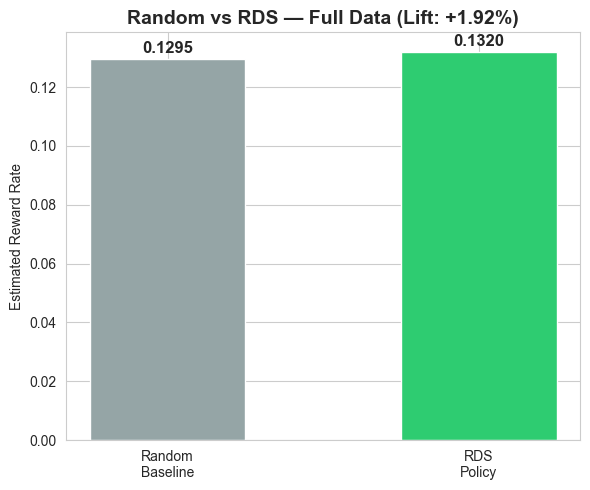

In [7]:
# Visual comparison
fig, ax = plt.subplots(figsize=(6, 5))

labels = ["Random\nBaseline", "RDS\nPolicy"]
values = [results["baseline"], results["target_value"]]
colors = ["#95a5a6", "#2ecc71" if results["lift"] > 0 else "#e74c3c"]

bars = ax.bar(labels, values, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_title(f"Random vs RDS — Full Data (Lift: {results['lift']:+.2%})", fontsize=14, fontweight="bold")
ax.set_ylabel("Estimated Reward Rate")
plt.tight_layout()
plt.show()

---
## 5. Importance Weight Analysis

To inspect weight distributions, we load a small sample from test data and compute weights on it.

In [8]:
# Load a small sample for weight inspection & visualization
import src.data_loader as _dl
_dl.USE_FULL_DATA = False

from src.data_loader import load_sample
from src.evaluation.importance_sampling import compute_importance_weights
import ast

eval_df = load_sample(n_rows=10_000, split="test")

target_probs_list = []
for i in range(len(eval_df)):
    eligible = eval_df["eligible_templates"].iloc[i]
    history = eval_df["history"].iloc[i]
    language = eval_df["ui_language"].iloc[i]

    if isinstance(eligible, str):
        eligible = ast.literal_eval(eligible)
    elif hasattr(eligible, 'tolist'):
        eligible = eligible.tolist()

    if history is None:
        history = []
    elif isinstance(history, str):
        history = ast.literal_eval(history)
    elif hasattr(history, 'tolist'):
        history = history.tolist()

    probs = policy.get_probabilities(eligible, history, language=language)
    target_probs_list.append(probs)

weights = compute_importance_weights(eval_df, target_probs_list, max_weight=MAX_WEIGHT)

[data_loader] Found 3 parquet files for 'test' split
[data_loader] === SAMPLE MODE ===
[data_loader] Loading 10,000 rows from 3 file(s)...
  Read part-00002-b6d6fc31-19ab-4361-8676-58414d2f5cad-c000.snappy.parquet: 1,966,945 rows so far
[data_loader] Raw data loaded: 10,000 rows in 4.2s
[data_loader] Memory (raw): 2.7 MB
[data_loader] Post-processing columns (parsing history & templates)...
[postprocess] Processing 10,000 rows in 1 batch(es) of 1,000,000...
  Batch 1/1: rows 0-10,000 done in 0.6s | Total: 10,000/10,000 (100%) | ETA: 0s
[postprocess] All 10,000 rows processed in 0.6s
[data_loader] Post-processing done in 0.6s
[data_loader] ✓ Final: 10,000 rows loaded in 4.8s total
[data_loader] Columns: ['datetime', 'ui_language', 'eligible_templates', 'history', 'selected_template', 'session_end_completed']
[data_loader] Memory (final): 3.6 MB
[importance_sampling] Weight statistics:
  Mean:   0.9857
  Std:    2.8043
  Min:    0.0000
  Max:    10.0000
  Median: 0.0000


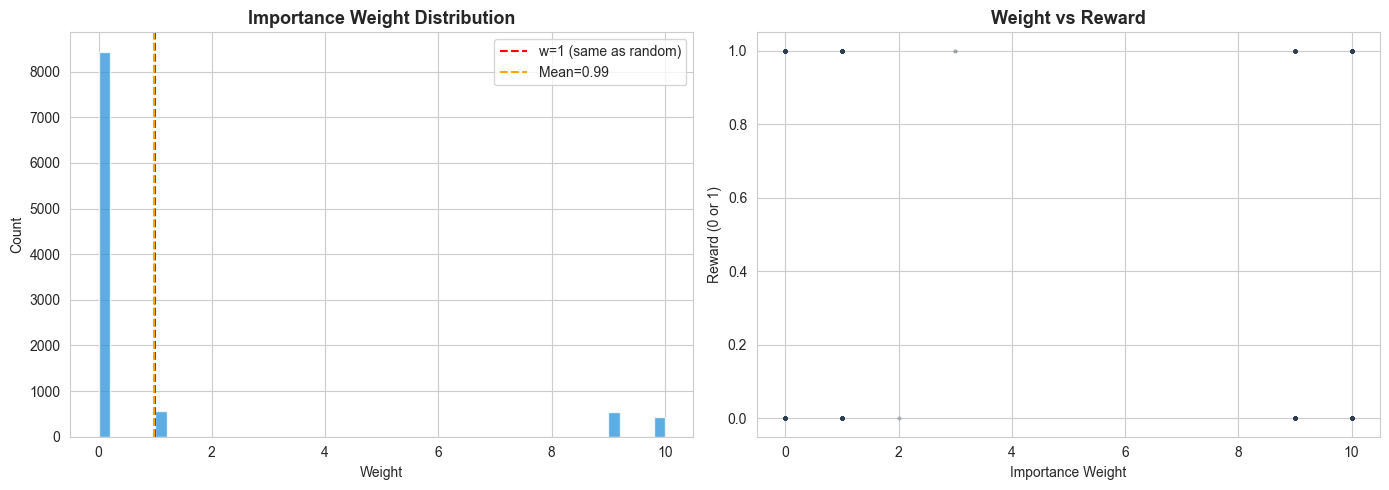

Effective Sample Size: 1,100 / 10,000 (11.0%)
Higher ESS = more reliable estimate. Lower ESS = a few events dominate.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram
axes[0].hist(weights, bins=50, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].axvline(x=1.0, color="red", linestyle="--", label="w=1 (same as random)")
axes[0].axvline(x=weights.mean(), color="orange", linestyle="--", label=f"Mean={weights.mean():.2f}")
axes[0].set_title("Importance Weight Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Weight")
axes[0].set_ylabel("Count")
axes[0].legend()

# Right: weight vs reward
rewards = eval_df["session_end_completed"].values
axes[1].scatter(weights, rewards, alpha=0.1, s=5, color="#2c3e50")
axes[1].set_title("Weight vs Reward", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Importance Weight")
axes[1].set_ylabel("Reward (0 or 1)")

plt.tight_layout()
plt.show()

ess = (np.sum(weights)**2) / np.sum(weights**2)
print(f"Effective Sample Size: {ess:,.0f} / {len(weights):,} ({ess/len(weights):.1%})")
print(f"Higher ESS = more reliable estimate. Lower ESS = a few events dominate.")

---
## 6. Hyperparameter Sensitivity

Since reward_rates and rds_scores are fixed (computed from full training data), we can quickly re-smooth with different κ values and re-evaluate. Only the smoothing + evaluation steps change — no need to re-read training data.

For evaluation speed, we use a sample from the test set.

In [13]:
# Hyperparameter sensitivity with paper-accurate settings
  # Re-uses fitted language-specific scores, only changes eval params

configs = [
      {"gamma": 0.017, "h": 15, "tau": 0.0025, "argmax": True,  "label": "Paper default (argmax)"},
      {"gamma": 0.017, "h": 15, "tau": 0.0025, "argmax": False, "label": "Softmax τ=0.0025"},
      {"gamma": 0.017, "h": 15, "tau": 0.005,  "argmax": False, "label": "Softmax τ=0.005"},
      {"gamma": 0.017, "h": 15, "tau": 0.01,   "argmax": False, "label": "Softmax τ=0.01"},
      {"gamma": 0.017, "h": 15, "tau": 0.02,   "argmax": False, "label": "Softmax τ=0.02"},
      {"gamma": 0.010, "h": 15, "tau": 0.0025, "argmax": True,  "label": "γ=0.010 (argmax)"},
      {"gamma": 0.025, "h": 15, "tau": 0.0025, "argmax": True,  "label": "γ=0.025 (argmax)"},
      {"gamma": 0.017, "h": 7,  "tau": 0.0025, "argmax": True,  "label": "h=7 (argmax)"},
      {"gamma": 0.017, "h": 30, "tau": 0.0025, "argmax": True,  "label": "h=30 (argmax)"},
  ]

print(f"Testing {len(configs)} configs (language-specific scores, 10K sample)...\n")
print(f"{'Config':<28} {'Baseline':>10} {'RDS Value':>10} {'Lift':>8}")
print("-" * 60)

hp_results = []
for cfg in configs:
    p = RDSPolicy(
        kappa=KAPPA, gamma=cfg["gamma"], h=cfg["h"],
        tau=cfg["tau"], use_argmax=cfg["argmax"],
      )
p.reward_rates = policy.reward_rates
p.rds_scores = policy.rds_scores
p.counts = policy.counts
p.smoothed_scores = dict(policy.smoothed_scores)
p.lang_smoothed_scores = policy.lang_smoothed_scores
p.use_language = True
p.is_fitted = True

r = p.evaluate(eval_df, max_weight=MAX_WEIGHT, sample_size=10_000)

print(f"{cfg['label']:<28} {r['baseline']:>10.6f} {r['target_value']:>10.6f} {r['lift']:>+8.2%}")
hp_results.append({**cfg, **r})

Testing 9 configs (language-specific scores, 10K sample)...

Config                         Baseline  RDS Value     Lift
------------------------------------------------------------
EVALUATING RDS POLICY

--- Step 1: Computing random baseline ---
[baseline] Random policy performance:
  Total notifications: 10,000
  User engaged: 1,843
  Baseline reward rate: 0.184300 (18.43%)

--- Step 2: Computing RDS probabilities for 10,000 events ---


Computing probabilities: 100%|█████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 76287.54it/s]


--- Step 3: Computing importance weights ---
[importance_sampling] Weight statistics:
  Mean:   0.9445
  Std:    2.7447
  Min:    0.0000
  Max:    10.0000
  Median: 0.0000

--- Step 4: Computing WIS estimate ---
[importance_sampling] WIS estimate: 0.191742
[importance_sampling] Effective sample size: 1,059 / 10,000 (10.6%)

--- Step 5: Computing lift ---

[baseline] RESULTS:
  Random baseline:  0.184300
  RDS policy:       0.191742
  Absolute gain:    +0.007442
  Relative lift:    +4.04%
  → Algorithm OUTPERFORMS random by 4.04%

EVALUATION COMPLETE
h=30 (argmax)                  0.184300   0.191742   +4.04%


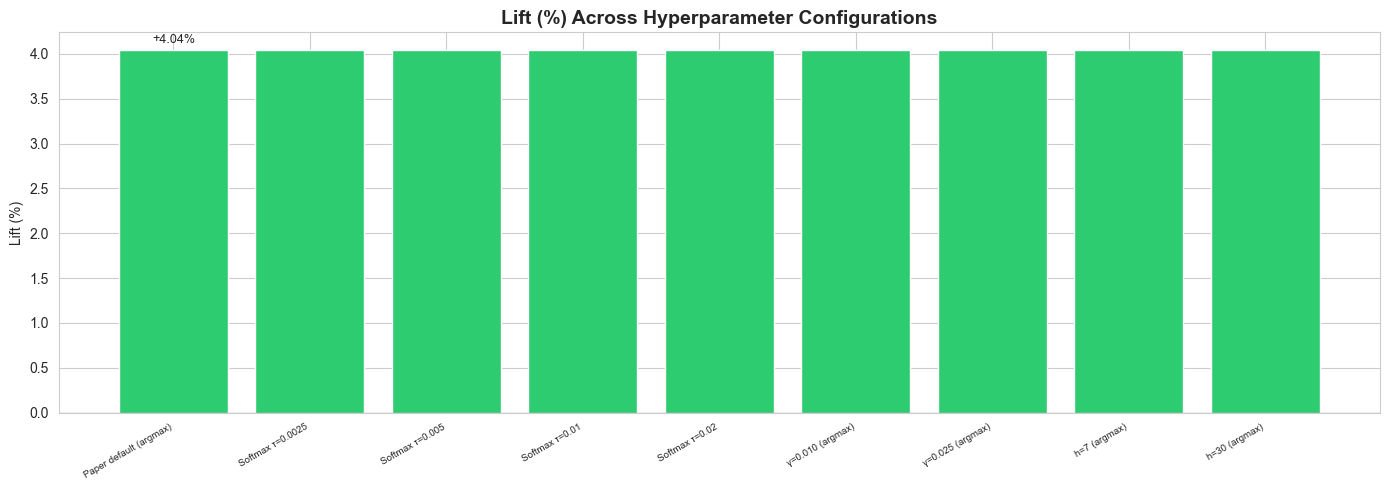

In [14]:
 # Lift comparison chart
 # Lift comparison chart
fig, ax = plt.subplots(figsize=(14, 5))

labels = [c["label"] for c in configs]
lifts = [r["lift"] for r in hp_results]
colors = ["#2ecc71" if l > 0 else "#e74c3c" for l in lifts]

bars = ax.bar(range(len(labels)), [l * 100 for l in lifts], color=colors, edgecolor="white")
ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=7, rotation=30, ha="right")
ax.set_title("Lift (%) Across Hyperparameter Configurations", fontsize=14, fontweight="bold")
ax.set_ylabel("Lift (%)")

for bar, l in zip(bars, lifts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
        f"{l:+.2%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

---
## 7. Final Summary — Everything We Built

| Notebook | Layer | What it does |
|----------|-------|-------------|
| **01** | Data | Explored dataset structure: 12 templates, sleeping arms, history, binary reward |
| **02** | Baseline | Random policy reward rate = the number to beat |
| **03** | RDS | Relative Difference Scores — removes confounding from user quality |
| **04** | Smoothing + Recency | Bayesian shrinkage (κ) + exponential decay penalty (γ, h) |
| **05** | Softmax | Temperature-controlled exploration/exploitation (τ) |
| **06** | Evaluation | **Full-data** fit + importance sampling evaluation → lift |

**Memory solution:** `fit_chunked` and `evaluate_chunked` stream through parquet files in 1M-row chunks. Peak RAM ~1-2 GB instead of 15+ GB.

**The full pipeline in one sentence:** Compute how much better each template performs compared to its peers (RDS), smooth noisy estimates (Bayesian), penalize recently-sent templates (recency), sample proportionally to scores (softmax), and measure improvement over random using importance weights.

### Next steps
1. Increase `EVAL_SAMPLE_SIZE` (or set to `None`) for more reliable lift estimates
2. Grid search over hyperparameters to find optimal (κ, γ, h, τ)
3. Compare against other baseline policies (e.g., greedy, epsilon-greedy)